### Exploratory Data Analysis (EDA) and Visualization
 **Goal:** Understand the shape, distributions, correlations, and anomalies in the California Housing Dataset before applying any machine learning algorithms.
 A machine learning model is only as good as the data it is fed. In this notebook, we will act as detectives to uncover:
 1. **Data Structure:** What types of data do we have? Are there missing values?
 2. **Distributions:** Are our features normally distributed, or are they skewed (tail-heavy)?
 3. **Geospatial Trends:** How does physical location impact house prices?
 4. **Correlations:** Which features have the strongest predictive power for our target (`median_house_value`)?
 5. **Outliers:** Are there extreme values that might confuse our future model?

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook",font_scale=1.2)
pd.set_option('display.max_columns',None)

print("Libraries imported successfully!")

Libraries imported successfully!


### Loading and Inspecting the Data
 Load the raw dataset and lets have a high-level look at its structure.

In [5]:
try:
    housing = pd.read_csv(r"../data/housing.csv")
    print(f"Dataset loaded successfully! \nShape: {housing.shape[0]} rows, {housing.shape[1]} columns.")
except FileNotFoundError:
    print("[Error] Dataset not found. Please ensure the data file is in the working directory.")

Dataset loaded successfully! 
Shape: 20640 rows, 10 columns.


In [6]:
display(housing.sample(5))

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
11534,-118.08,33.76,26.0,996.0,364.0,366.0,313.0,1.2813,46700.0,<1H OCEAN
17650,-121.88,37.26,25.0,3025.0,689.0,1755.0,661.0,3.8893,218600.0,<1H OCEAN
3752,-118.38,34.17,33.0,1588.0,454.0,739.0,392.0,2.8208,238500.0,<1H OCEAN
9495,-123.81,39.34,17.0,1981.0,371.0,773.0,325.0,3.1563,277000.0,<1H OCEAN
11546,-118.04,33.74,26.0,2532.0,421.0,1274.0,441.0,5.3559,235800.0,<1H OCEAN


### High-Level Data Summaries
 We need to know the data types (integers, floats, objects/strings) and immediately identify if we are dealing with missing data.

In [7]:
print("--- DATA TYPES AND MISSING VALUES ---")
housing.info()

--- DATA TYPES AND MISSING VALUES ---
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [8]:
print("\n--- EXACT MISSING VALUE COUNTS ---")
missing_values = housing.isnull().sum()
print(missing_values[missing_values > 0])


--- EXACT MISSING VALUE COUNTS ---
total_bedrooms    207
dtype: int64


**Observation on Missing Data:** 
Notice that `total_bedrooms` has missing entries. We cannot feed `NaN` (Not a Number) values into standard Machine Learning models. We will handle these missing values via Imputation in future work.

Now, let's look at the statistical summary of the numerical columns.


In [9]:
print("\n--- DESCRIPTION OF THE DATASET ---")
display(housing.describe())


--- DESCRIPTION OF THE DATASET ---


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


### Categorical Feature Analysis
 Most of our data is numerical, but `ocean_proximity` is a categorical text feature. Let's see how the categories are distributed.


--- Categorical Feature Analysis ---

Total categorical value counts per category : 
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


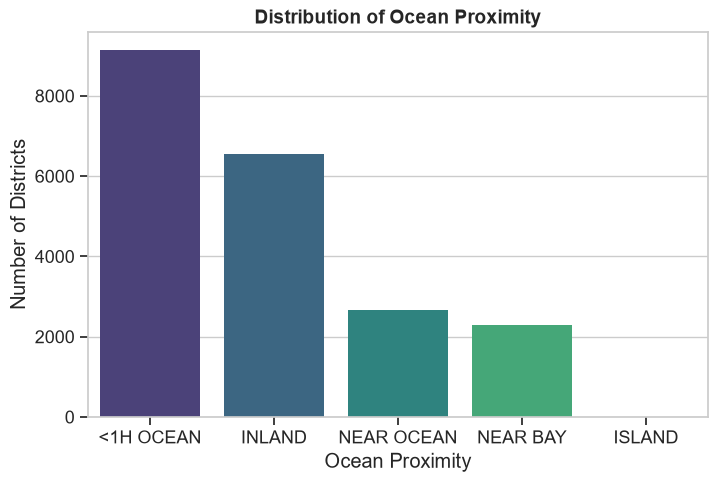

In [10]:
print("\n--- Categorical Feature Analysis ---\n")
ocean_counts = housing['ocean_proximity'].value_counts()
print(f"Total categorical value counts per category : \n{ocean_counts}")

plt.figure(figsize=(8,5))
sns.barplot(x=ocean_counts.index , y=ocean_counts.values,palette = "viridis",hue=ocean_counts.index , legend = False)
plt.title("Distribution of Ocean Proximity" , fontsize=14 , fontweight='bold')
plt.ylabel("Number of Districts")
plt.xlabel("Ocean Proximity")
plt.show()

### Univariate Analysis (Distributions)
 Let's plot histograms for every numerical attribute. 
 
 **What to look for:**
 * **Different Scales:** Notice how `median_income` ranges from 0-15, but `median_house_value` ranges from 0-500,000. Need Feature Scaling (Standardization).
 * **Tail-Heavy Distributions:** Many features (like `total_rooms`, `population`) extend much further to the right of the median than to the left.
 * **Capped Values:** Looking closely at `housing_median_age` and `median_house_value`. There is a massive spike at the far right. The data was likely capped at 50 years and $500,000.

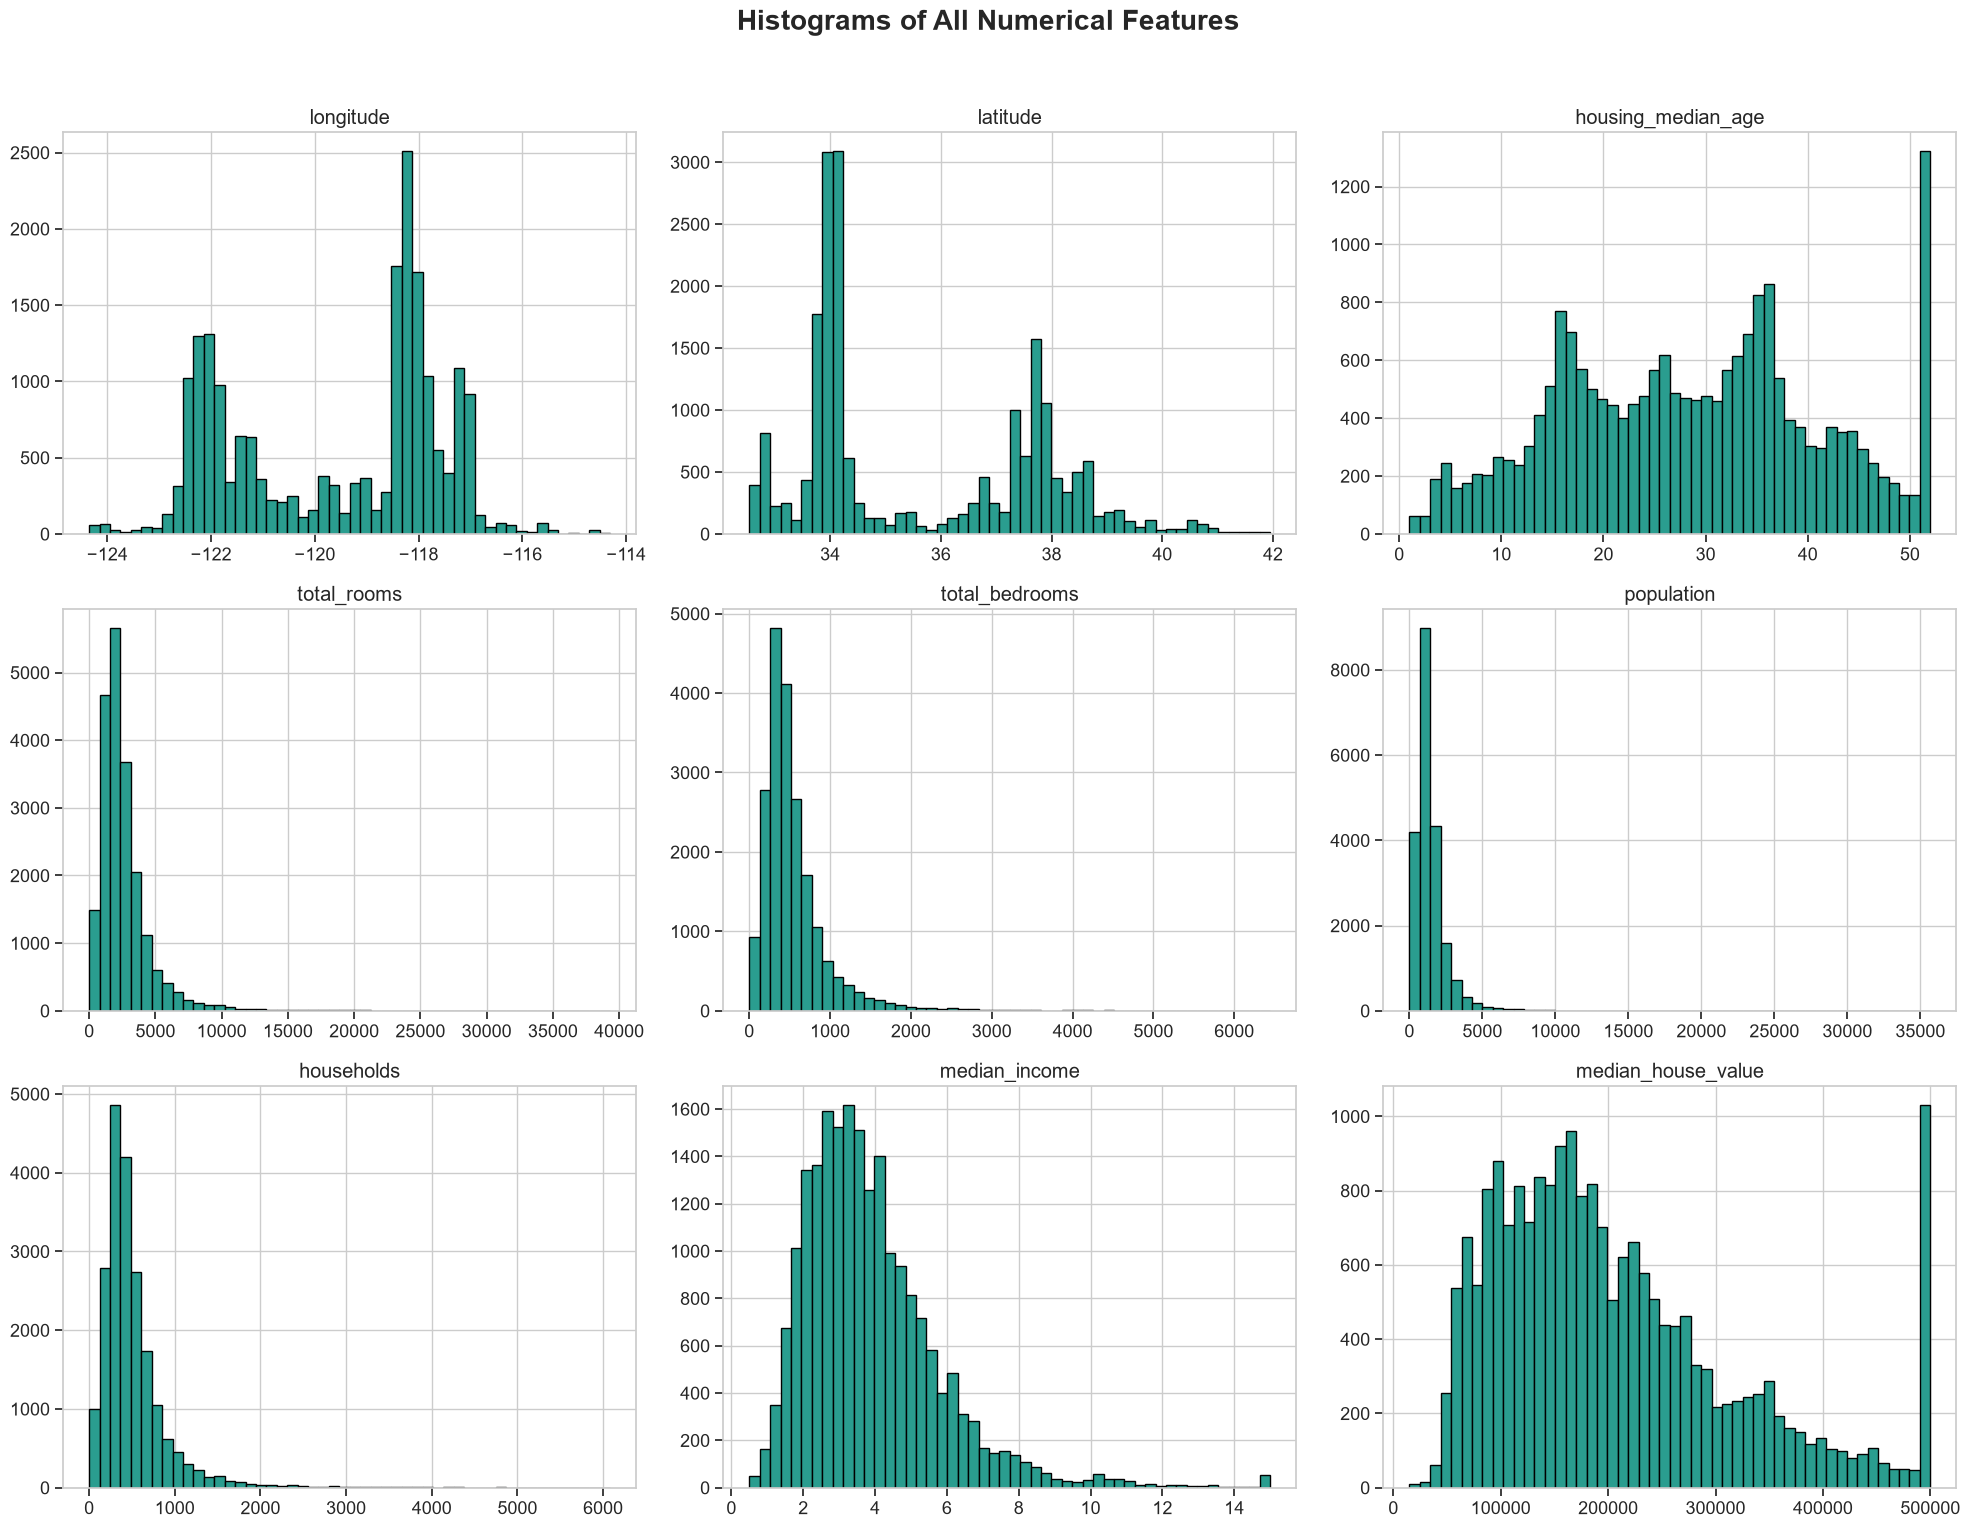

In [11]:
housing.hist(bins=50, figsize=(20, 15), color='#2A9D8F', edgecolor='black')
plt.suptitle("Histograms of All Numerical Features", fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Step 5: Geospatial Analysis (The Map)
 We have latitude and longitude, we can plot the data geographically.

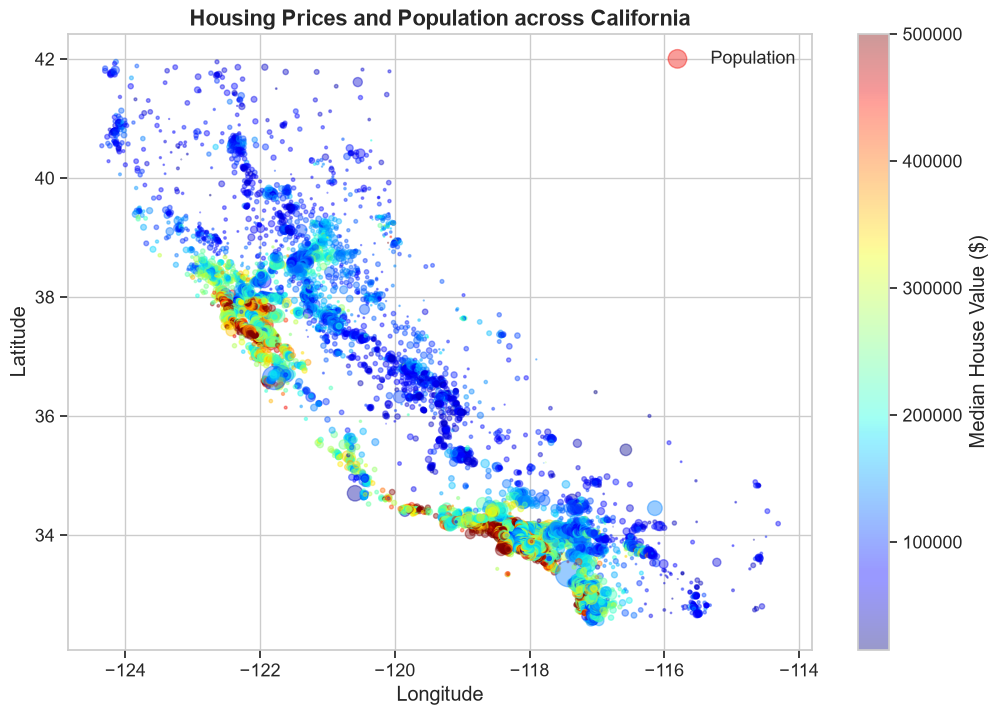

In [12]:
plt.figure(figsize=(12, 8))
# s = size (population), c = color (median_house_value)
scatter = plt.scatter(x=housing['longitude'], y=housing['latitude'], 
                      alpha=0.4, 
                      s=housing['population']/100, label="Population", 
                      c=housing['median_house_value'], cmap=plt.get_cmap("jet"))

plt.colorbar(scatter, label="Median House Value ($)")
plt.title("Housing Prices and Population across California", fontsize=16, fontweight='bold')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()

**Geospatial Insights:**
 The plot clearly maps out the state of California! The red/orange areas (high prices) perfectly cluster around the Bay Area and Los Angeles coastlines. The model will definitely need to learn that location (`ocean_proximity` and coordinates) is a massive predictor of price.

### Correlation Analysis
 How much does each feature linearly correlate with the `median_house_value`? 
 * **1.0** = Perfect positive correlation (As feature goes up, price goes up).
 * **-1.0** = Perfect negative correlation (As feature goes up, price goes down).
 * **0.0** = No linear correlation.

In [13]:
numeric_housing = housing.select_dtypes(include=[np.number])
corr_matrix = numeric_housing.corr()


Correlation specifically with our target variable

In [14]:
print("Correlation with Median House Value:")
print(corr_matrix["median_house_value"].sort_values(ascending=False))

Correlation with Median House Value:
median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


Visualizing the entire correlation matrix via a Heatmap

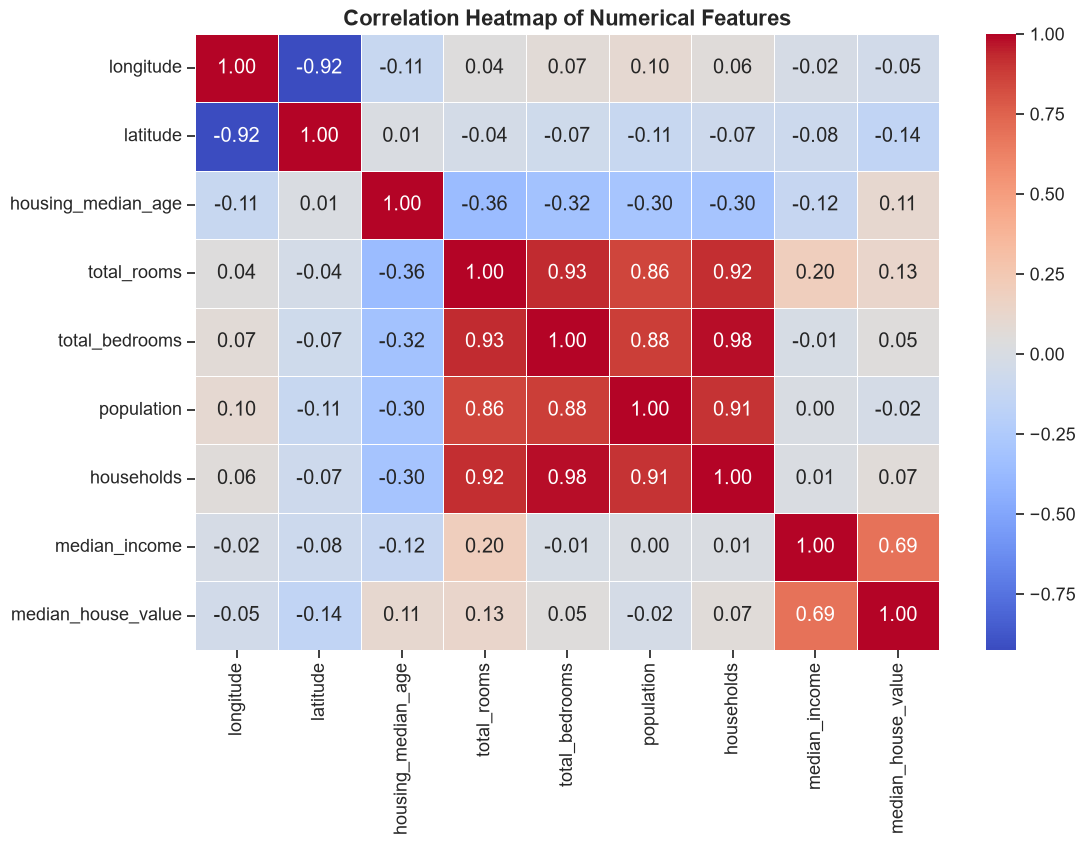

In [15]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features", fontsize=16, fontweight='bold')
plt.show()

### Zooming in on the Strongest Predictor
 The heatmap reveals that `median_income` has the highest correlation (~0.68) with house values. Let's plot these two features against each other.

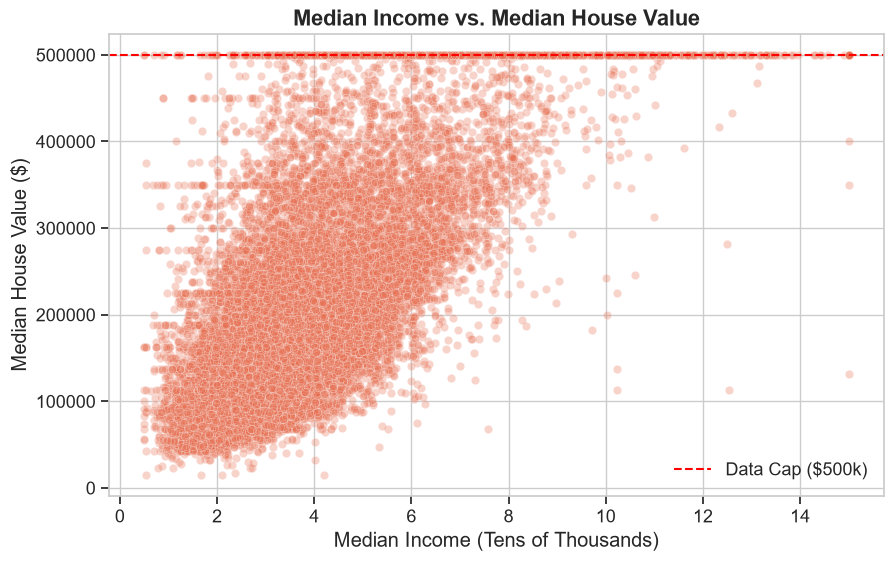

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=housing['median_income'], y=housing['median_house_value'], alpha=0.3, color='#E76F51')
plt.title("Median Income vs. Median House Value", fontsize=16, fontweight='bold')
plt.xlabel("Median Income (Tens of Thousands)")
plt.ylabel("Median House Value ($)")

# Highlighting the price cap anomaly
plt.axhline(y=500000, color='r', linestyle='--', label='Data Cap ($500k)')
plt.legend()
plt.show()

**Critical Insight:**
 1. The upward trend is obvious; higher income heavily dictates higher house prices.
 2. **The Anomaly:** Looking at the horizontal line of data points strictly at the $500,000 mark. This confirms our histogram observation that the data was artificially capped. We also see faint horizontal lines around $450k and $350k. 
 
 *Note for future notebooks and model training : We may need to remove districts where the price is exactly $500,001 to prevent the model from learning these artificial quirks.*

### Outlier Detection
 Let's use Box Plots to look for extreme statistical outliers in our feature set, which might skew algorithms like Linear Regression.


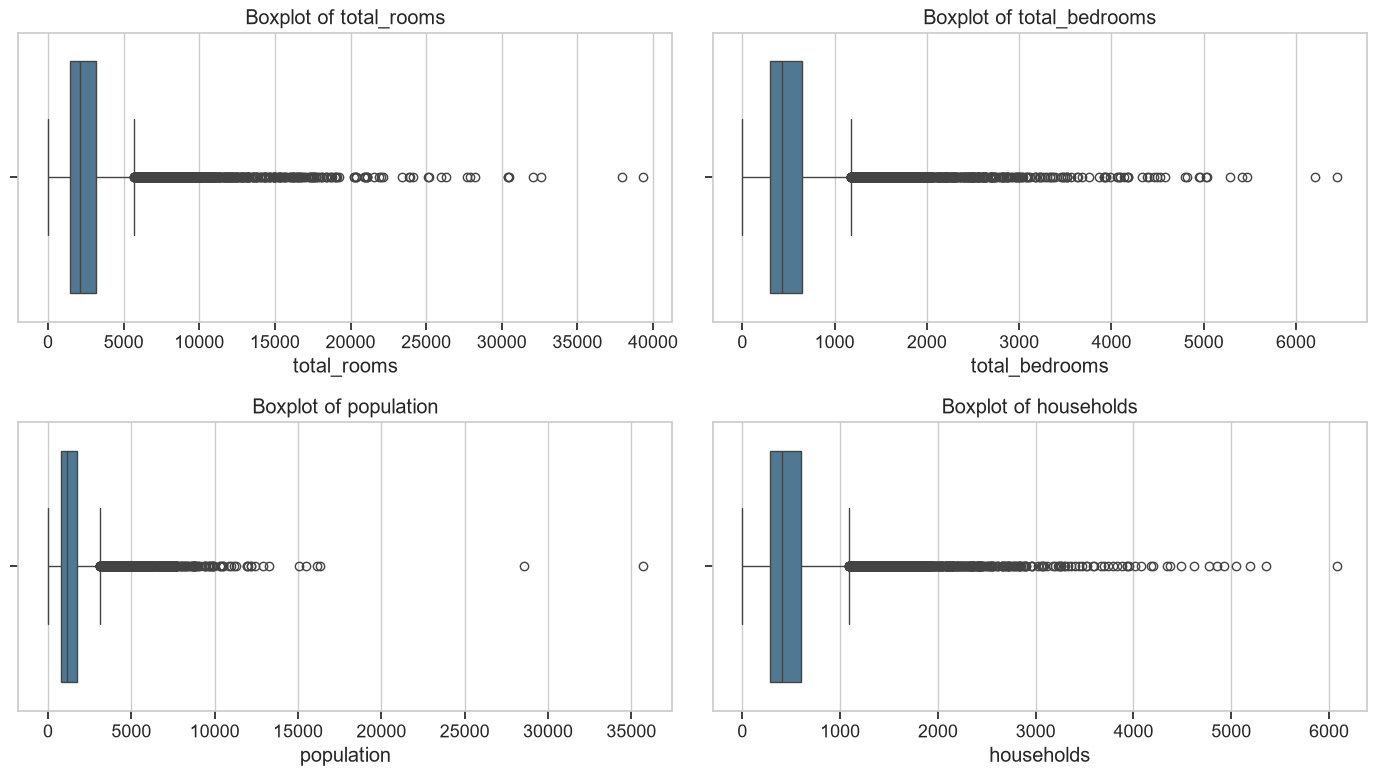

In [17]:
features_to_check = ['total_rooms', 'total_bedrooms', 'population', 'households']

plt.figure(figsize=(14, 8))
for i, feature in enumerate(features_to_check, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=housing[feature], color="#457B9D")
    plt.title(f"Boxplot of {feature}")

plt.tight_layout()
plt.show()

**Outlier Insights:**
 There are massive outliers in `total_rooms` and `population`. A district with 35,000 rooms is highly unusual. 
 However, this happens because these are *totals per district*. A district with many people will naturally have many rooms. 